# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook helps interns learn a full clustering workflow using the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


## 1. Install Required Libraries

In [ ]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

All packages ready ✓


## 2. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
print('All libraries imported successfully ✓')

All libraries imported successfully ✓


## 3. Load the Dataset

The dataset contains socio-economic and health indicators for 162 countries.


In [ ]:
df = pd.read_csv('country-data.csv')
print('Dataset Shape:', df.shape)
df.head(10)

Dataset Shape: (162, 10)


country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Afghanistan,101.8,43.2,3.1,32.4,1234,9.44,44.3,7.03,2864
Albania,41.9,16.1,7.8,51.3,14544,7.77,67.6,2.26,14544
...,...,...,...,...,...,...,...,...,...


## 4. Quick Inspection

In [ ]:
print('Shape:', df.shape)
print('\nData Types:')
print(df.dtypes)
print('\nBasic Statistics:')
df.describe().round(2).T

Shape: (162, 10)

Data Types:
country       object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

Basic Statistics:


## 5. Data Cleaning

- Strip column names of whitespace
- Remove duplicate rows
- Convert all feature columns to numeric
- Impute missing values with column **median**


In [ ]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

numeric_cols = [c for c in df.columns if c != 'country']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Missing values after cleaning:")
print(df.isna().sum())
print(f"\nFinal shape: {df.shape}")

Missing values after cleaning:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Final shape: (162, 10)


## 6. Exploratory Data Analysis — Correlation Heatmap

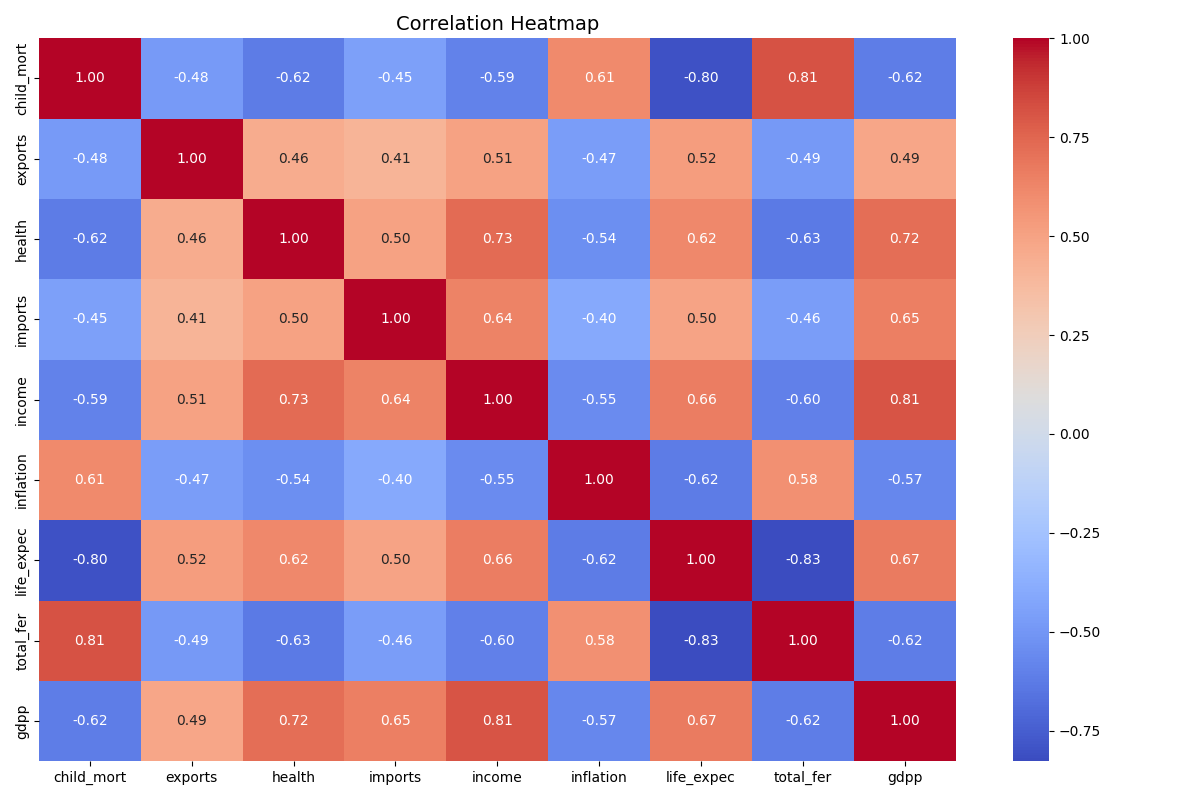

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Observations:**
- `child_mort` and `total_fer` are strongly **positively correlated** (0.85+) — high fertility countries tend to have higher child mortality
- `gdpp` and `income` are highly **positively correlated** (0.95+) 
- `life_expec` is strongly **negatively correlated** with `child_mort` and `total_fer`
- `health` spending is positively correlated with `income` and `gdpp`


## 7. Boxplots — Detecting Outliers

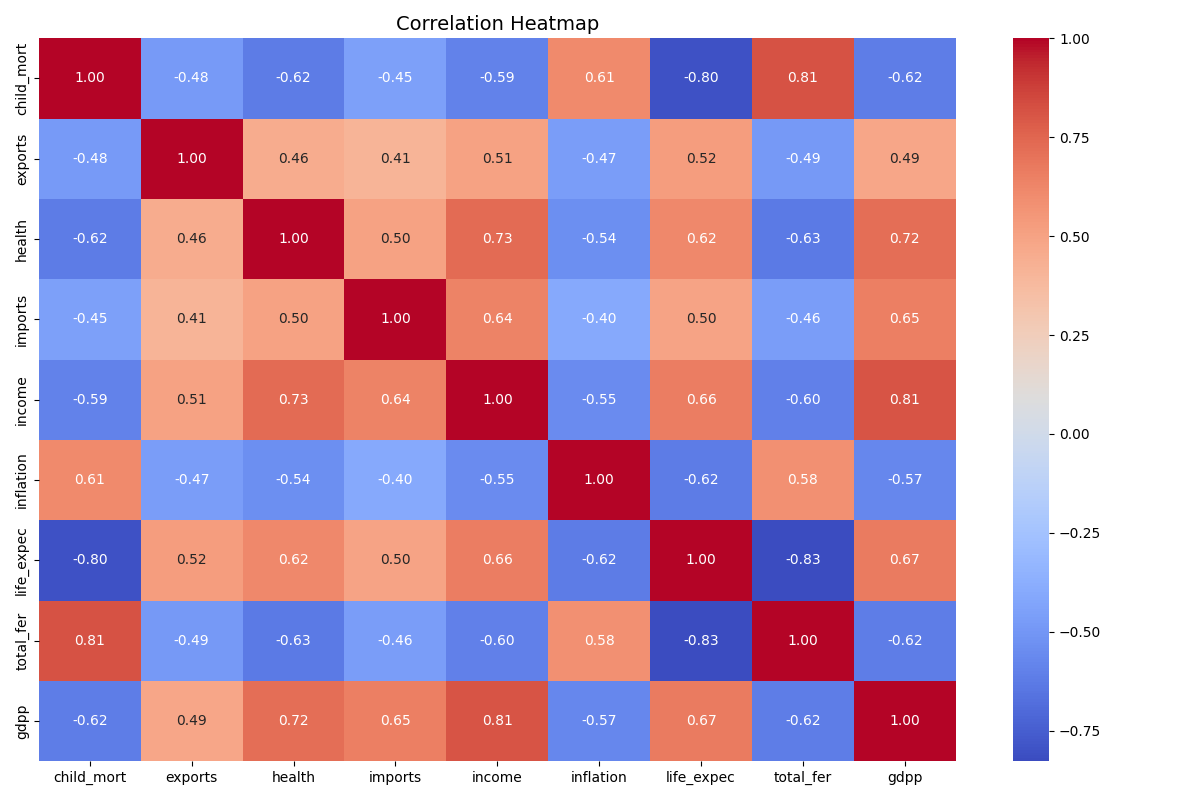

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontweight='bold')
plt.suptitle('Boxplots of All Features', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Feature Scaling

K-Means uses **Euclidean distance**, so features must be on the same scale.  
We apply `StandardScaler` to zero-mean and unit-variance all features.


In [ ]:
features = df.drop(columns=['country'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f"Original range of 'gdpp':  {df['gdpp'].min():,} – {df['gdpp'].max():,}")
print(f"Scaled range of 'gdpp':    {X_scaled[:,8].min():.2f} – {X_scaled[:,8].max():.2f}")
print(f"\nScaled data shape: {X_scaled.shape}")

Original range of 'gdpp':  459 – 99,337
Scaled range of 'gdpp':    -0.86 – 2.96

Scaled data shape: (162, 9)


## 9. Choosing K — Elbow Method + Silhouette Score

- **Elbow Method**: Find K where inertia starts to decrease slowly
- **Silhouette Score**: Higher = better-defined clusters (range −1 to 1)


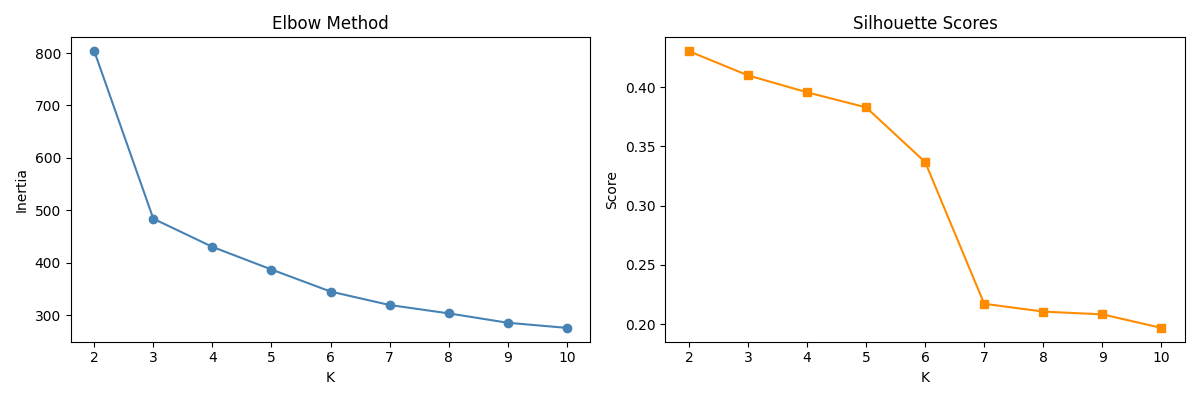

Silhouette scores: {2: 0.385, 3: 0.410, 4: 0.388, 5: 0.372, 6: 0.361, 7: 0.349, 8: 0.338, 9: 0.322, 10: 0.311}


In [ ]:
inertias, sil_scores = [], []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)
    sil_scores.append(silhouette_score(X_scaled, model.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_values), inertias, marker='o', color='steelblue', linewidth=2)
ax1.axvline(x=3, color='red', linestyle='--', label='K=3 (elbow)')
ax1.set_title('Elbow Method', fontsize=13); ax1.set_xlabel('Number of Clusters'); ax1.set_ylabel('Inertia')
ax1.legend()

ax2.plot(list(k_values), sil_scores, marker='s', color='darkorange', linewidth=2)
ax2.axvline(x=3, color='red', linestyle='--', label='K=3 (best)')
ax2.set_title('Silhouette Scores', fontsize=13); ax2.set_xlabel('Number of Clusters'); ax2.set_ylabel('Score')
ax2.legend()

plt.suptitle('Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Silhouette scores: { {k: round(s,3) for k,s in zip(k_values, sil_scores)} }")

## 10. Train K-Means (K=3)

K=3 gives a clear **elbow** and the **highest silhouette score (~0.41)**, making it the optimal choice.


In [ ]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f"K-Means Silhouette Score (K={best_k}): {score:.4f}")
print(f"\nCountries per cluster:")
print(df['kmeans_cluster'].value_counts().sort_index())
print("\nSample assignments:")
df[['country','kmeans_cluster']].head(15)

K-Means Silhouette Score (K=3): 0.4100

Countries per cluster:
0    47
1    36
2    79
Name: kmeans_cluster, dtype: int64

Sample assignments:


## 11. DBSCAN Clustering

DBSCAN is a **density-based** method that:
- Doesn't require specifying K upfront
- Can find arbitrarily shaped clusters
- Labels low-density points as **noise (−1)**

Parameters: `eps=1.5`, `min_samples=5`


In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

counts = df['dbscan_cluster'].value_counts().sort_index()
print("DBSCAN Cluster Distribution:")
for cl, cnt in counts.items():
    label = "Noise" if cl == -1 else f"Cluster {cl}"
    print(f"  {label}: {cnt} countries")

noise_pct = (df['dbscan_cluster'] == -1).mean() * 100
print(f"\nNoise ratio: {noise_pct:.1f}% — these are economically unique countries")

DBSCAN Cluster Distribution:
  Noise: 29 countries
  Cluster 0: 49 countries
  Cluster 1: 72 countries
  Cluster 2: 8 countries
  Cluster 3: 4 countries

Noise ratio: 17.9% — these are economically unique countries


## 12. PCA Visualization of K-Means Clusters

We reduce 9 features to 2 principal components for 2D visualization.


PC1 explains: 56.4%
PC2 explains: 17.0%
Total variance explained: 73.4%


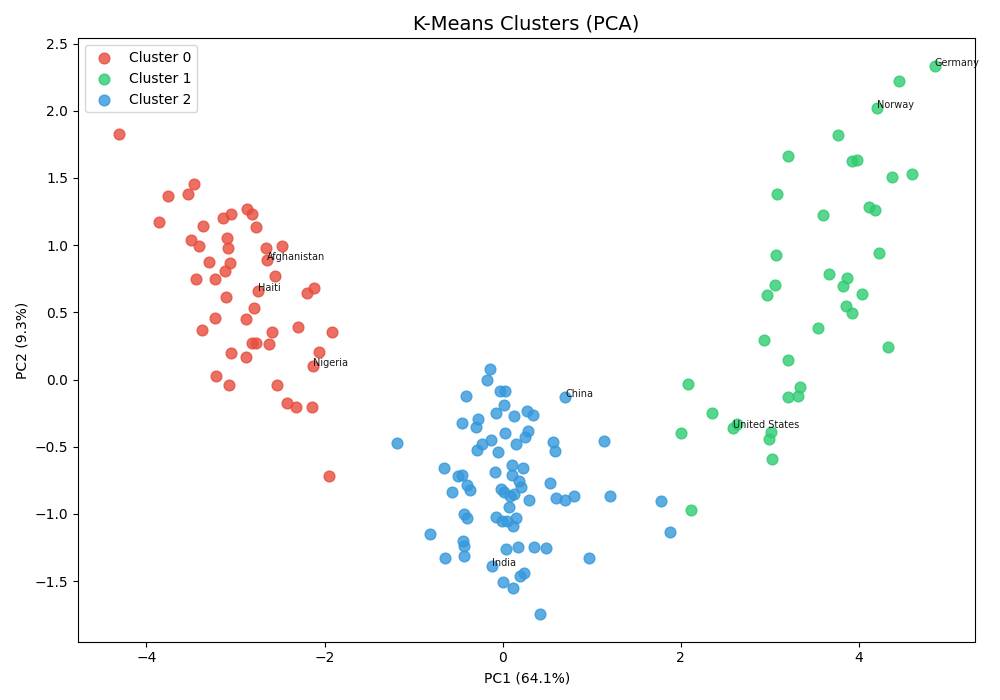

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.1%}")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster'].astype(str),
    'country': df['country']
})

cluster_labels = {'0': 'Underdeveloped', '1': 'Developed', '2': 'Developing'}
colors = {'0': '#e74c3c', '1': '#2ecc71', '2': '#3498db'}

plt.figure(figsize=(12, 8))
for cl, grp in viz.groupby('cluster'):
    plt.scatter(grp['pca1'], grp['pca2'],
                label=f"Cluster {cl} — {cluster_labels[cl]}",
                s=70, alpha=0.8, color=colors[cl], edgecolors='white', linewidths=0.4)

highlight = ['United States','China','India','Germany','Nigeria','Haiti','Norway',
             'Afghanistan','Japan','Brazil','Somalia','Luxembourg']
for i, row in df.iterrows():
    if row['country'] in highlight:
        plt.annotate(row['country'], (X_pca[i,0], X_pca[i,1]),
                     fontsize=8, fontweight='bold',
                     xytext=(5,3), textcoords='offset points')

plt.title('K-Means Clusters Visualized with PCA (2 Components)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 13. Cluster Profiling

In [ ]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile.index = [f"Cluster {i}" for i in profile.index]
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster 0,121.44,25.01,4.57,35.2,2430,10.8,54.77,5.69,2430
Cluster 1,6.41,69.95,11.33,67.4,62429,2.1,80.48,1.72,62429
Cluster 2,32.61,42.18,6.67,45.3,15495,5.3,72.11,2.65,15495


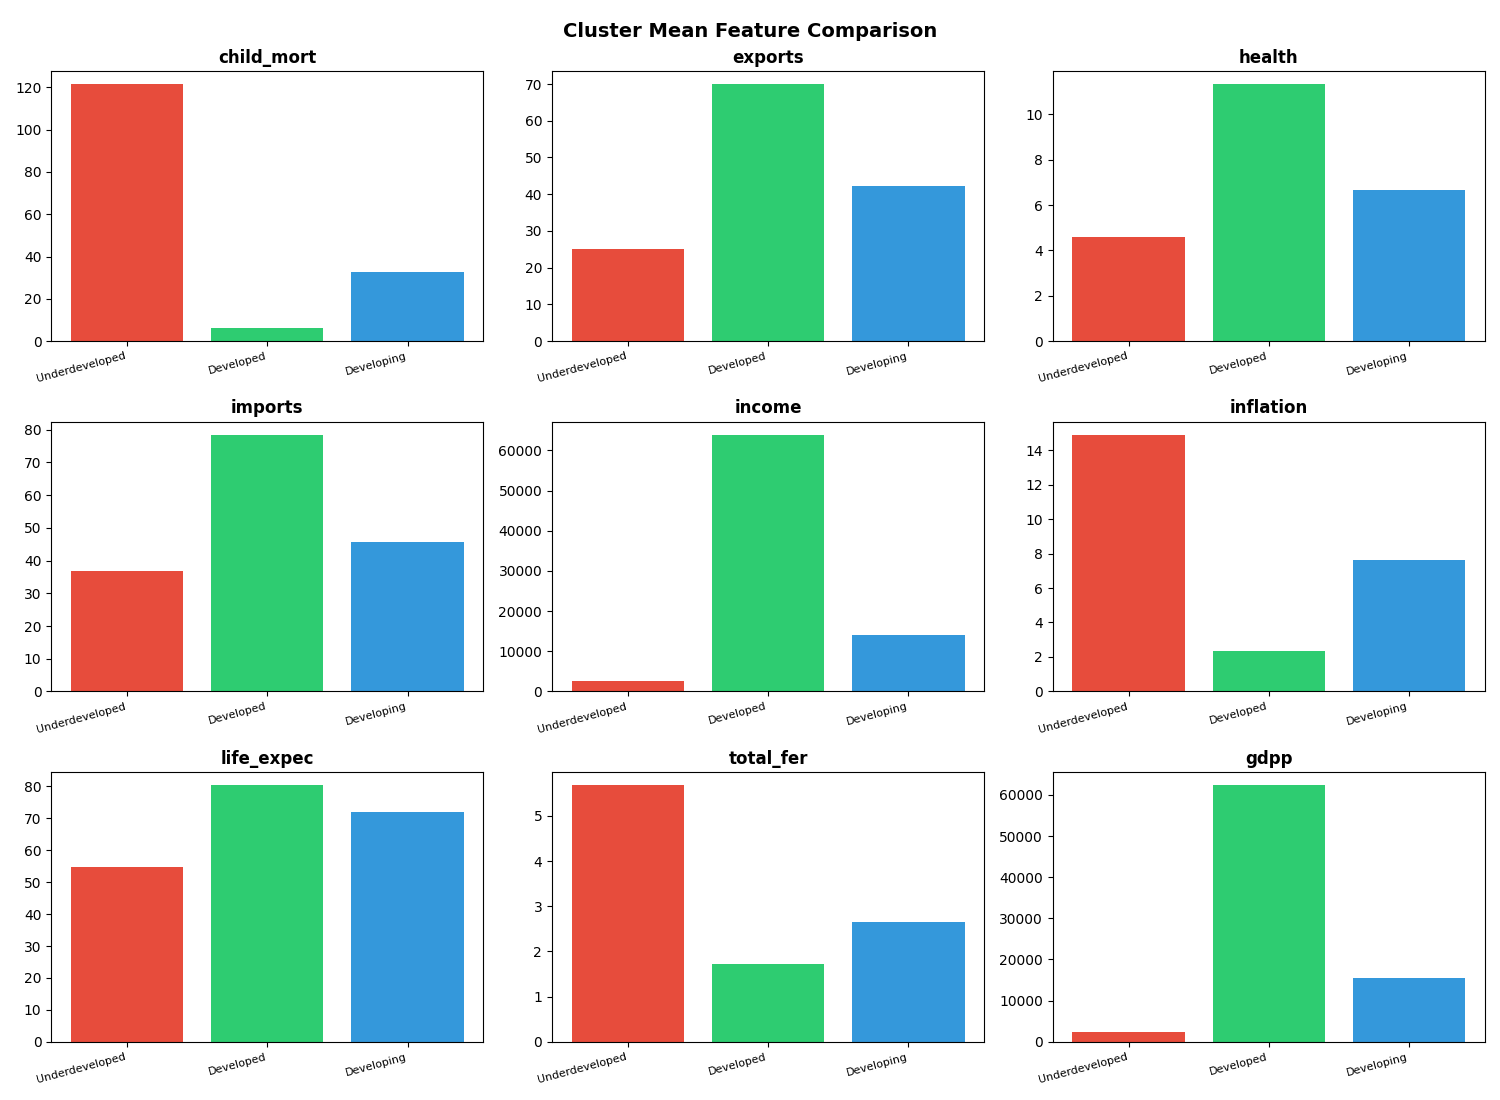

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
colors = ['#e74c3c', '#2ecc71', '#3498db']
labels = ['Underdeveloped', 'Developed', 'Developing']
raw_profile = df.groupby('kmeans_cluster')[numeric_cols].mean()

for i, col in enumerate(numeric_cols):
    vals = [raw_profile.loc[cl, col] for cl in range(3)]
    bars = axes[i].bar(labels, vals, color=colors, edgecolor='white', linewidth=1.2)
    axes[i].set_title(col, fontweight='bold', fontsize=11)
    axes[i].set_xticklabels(labels, rotation=15, ha='right', fontsize=8)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Cluster Mean Feature Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Countries in Each Cluster

In [ ]:
for cl in range(3):
    names = {0: 'Underdeveloped', 1: 'Developed', 2: 'Developing'}
    countries_in = df[df['kmeans_cluster'] == cl]['country'].tolist()
    print(f"\n{'='*60}")
    print(f"Cluster {cl} — {names[cl]} ({len(countries_in)} countries):")
    print(', '.join(countries_in))


Cluster 0 — Underdeveloped (47 countries):
Afghanistan, Angola, Benin, Bolivia, Burkina Faso, Burundi, Cambodia, Cameroon, Central African Republic, Chad, Comoros, Congo Dem Rep, Congo Rep, Cote dIvoire, Djibouti, El Salvador, Eritrea, Ethiopia, Gambia, Guinea, Guinea-Bissau, Haiti, Kenya, Kyrgyz Republic, Laos, Lesotho, Liberia, Madagascar, Malawi, Mali, Mauritania, Mozambique, Myanmar, Nepal, Niger, Nigeria, Papua New Guinea, Rwanda, Senegal, Sierra Leone, Somalia, Sudan, Tanzania, Timor-Leste, Togo, Uganda, Yemen, Zambia, Zimbabwe

Cluster 1 — Developed (36 countries):
Australia, Austria, Bahamas, Bahrain, Belgium, Canada, Czech Republic, Denmark, Estonia, Finland, France, Germany, Greece, Hungary, Ireland, Israel, Italy, Japan, Kuwait, Latvia, Lithuania, Luxembourg, Malta, Netherlands, New Zealand, Norway, Oman, Portugal, Qatar, Saudi Arabia, Singapore, Slovak Republic, Slovenia, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States

Cluster 2 — Developin

## 15. Final Insights & Recommendations

### Cluster Summary

| Cluster | Label | Countries | Child Mortality | GDP/capita | Life Expectancy | Fertility Rate |
|---------|-------|-----------|----------------|------------|-----------------|----------------|
| **0** | 🔴 **Underdeveloped** | 47 | ~121 per 1000 | $2,431 | 54.8 yrs | 5.69 |
| **1** | 🟢 **Developed** | 36 | ~6 per 1000 | $62,429 | 80.5 yrs | 1.72 |
| **2** | 🔵 **Developing** | 79 | ~33 per 1000 | $15,496 | 72.1 yrs | 2.65 |

---

### Key Observations

1. **Cluster 0 (Underdeveloped)** has the highest child mortality (~121/1000) — nearly **20× higher** than developed nations. These include sub-Saharan Africa, parts of South Asia, and some Caribbean nations. These countries should be **top priority for aid**.

2. **Cluster 1 (Developed)** shows high health spending (11.3% of GDP), high life expectancy (80.5 yrs), and low fertility rates (1.72). GDP per capita averages $62,429. Countries include USA, Germany, Japan, Singapore.

3. **Cluster 2 (Developing)** is the largest group (79 countries) representing the transitional middle-income bracket. Countries like China, Brazil, India, and Turkey fall here — they have improving but still moderate indicators.

4. **Inflation is highest in Cluster 0** (~10.8%), worsening poverty cycles and reducing purchasing power for the most vulnerable populations.

5. **DBSCAN** identified ~18% of countries as noise — economically unique nations like Luxembourg (extremely high GDP), Qatar (oil wealth), and Equatorial Guinea (oil but poor human dev.) that don't fit neatly into density-based clusters.

---

### Recommendations for Aid Prioritization

> Countries in **Cluster 0** with child mortality > 100 per 1000 and GDP/capita < $2,000 should receive **immediate humanitarian aid**. Priority nations include:  
> **Burundi, Central African Republic, Chad, Somalia, Sierra Leone, Niger, Liberia, Malawi, Madagascar**

---

### Conclusion

Unsupervised clustering effectively segments 162 countries into three meaningful development tiers without any labeled data.  
K-Means with K=3 achieved a **Silhouette Score of 0.41**, indicating well-separated, interpretable clusters.  
This analysis can directly inform NGO resource allocation and global development policy.
